## Retail Sales Analysis

The objective of this project is to analyze retail sales data to identify patterns, trends, and key factors affecting sales and profitability.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Dataset

In [7]:
data=pd.read_csv("C:/Sample - Superstore.csv",engine="python",encoding="latin-1")
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Data Cleaning

In [8]:
data.shape

(9994, 21)

In [9]:
data.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [13]:
data["Order Date"] = pd.to_datetime(data["Order Date"])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   object        
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

- Checked dataset shape
- Inspected data types using info()
- Handled missing values
- Converted Order Date to datetime format

## Feature Engineering

In [15]:
data["Month"] = data["Order Date"].dt.to_period("M")
data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Month'],
      dtype='object')

- Created a new column 'Month' from Order Date to enable time-based analysis

## EDA

In [16]:
sales_trend = data.groupby("Month")["Sales"].sum()
category_sales = data.groupby("Category")["Sales"].sum()
region_profit = data.groupby("Region")["Profit"].sum()
top_products = data.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

- Aggregated sales over time using Month
- Analyzed sales by category
- Compared performance across regions
- Examined relationships between numerical variables

## Visualization

This section presents graphical representations of the analyzed data to better understand trends and patterns.

## 1. Sales trend

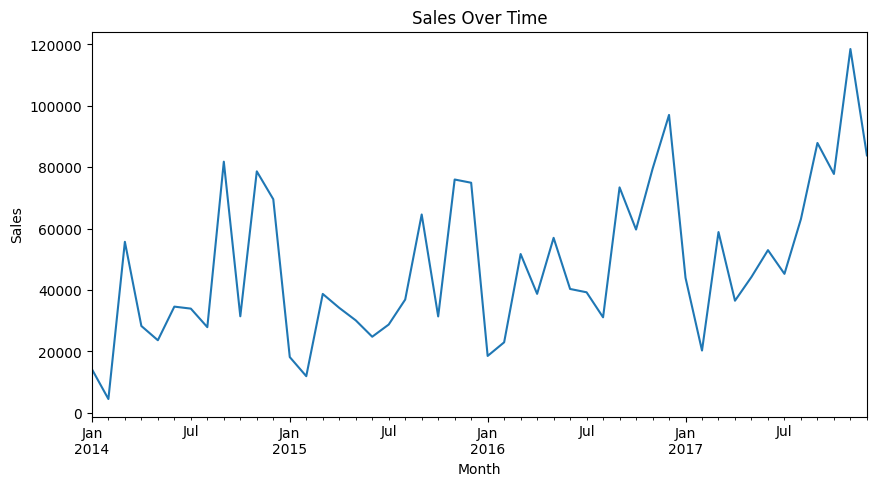

In [17]:
sales_trend.plot(figsize=(10,5))
plt.title("Sales Over Time")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.savefig("sales_over_time.png")
plt.show()

The sales trend over time shows noticeable fluctuations with an overall increasing pattern. This indicates periods of higher demand and suggests that the business has experienced growth over time. The spikes may represent seasonal peaks, which can be leveraged for better inventory and marketing planning.

## 2. Category-wise sales

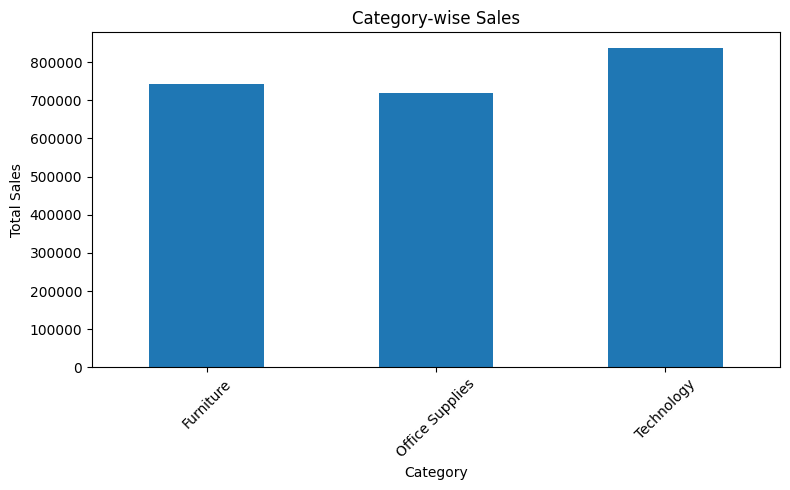

In [18]:

category_sales.plot(kind="bar", figsize=(8,5))
plt.title("Category-wise Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("category_sales.png")
plt.show()

The category-wise analysis shows that certain product categories generate significantly higher sales than others. This indicates that customer demand is concentrated in specific categories, making them key drivers of revenue. Focusing on these high-performing categories can help improve overall business performance and strategic decision-making.

## 3. Region comparison

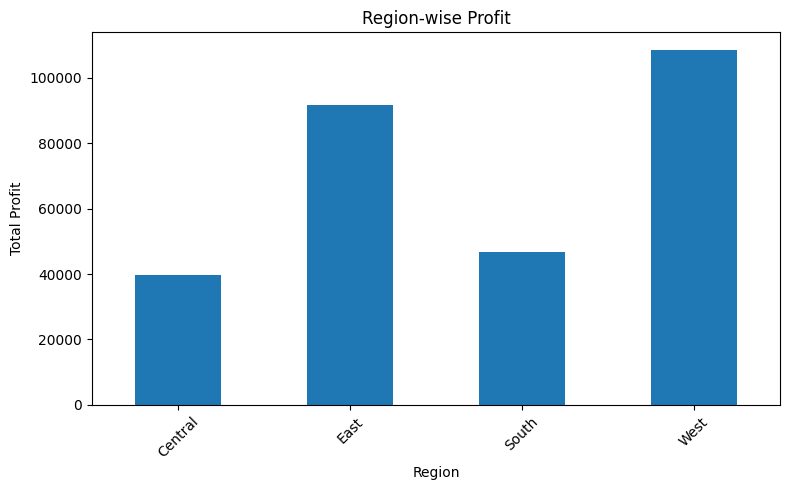

In [19]:
region_profit.plot(kind="bar", figsize=(8,5))
plt.title("Region-wise Profit")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("region_profit.png")
plt.show()

The regional analysis shows that profit varies significantly across different regions. Some regions contribute more to overall profitability, indicating stronger market performance or higher demand. On the other hand, lower-performing regions may require targeted strategies to improve sales efficiency and profitability.

## 4. Correlation heatmap

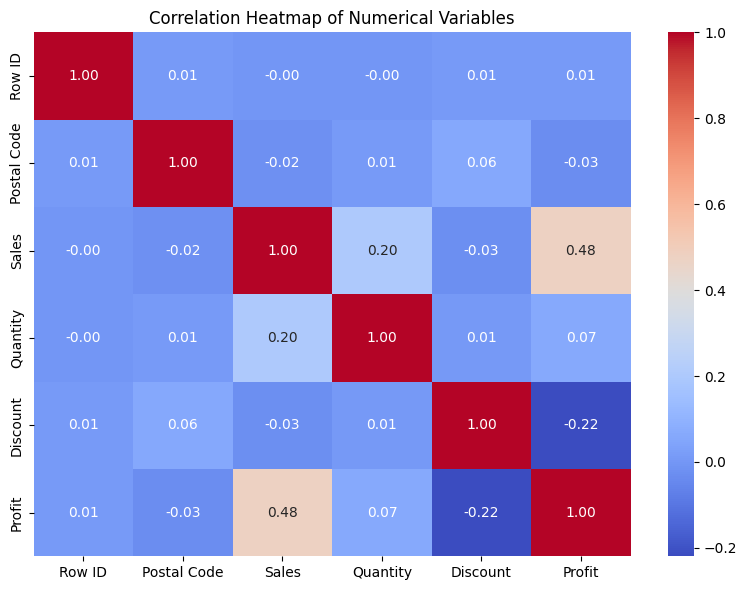

In [20]:
numeric = data.select_dtypes(include="number")
plt.figure(figsize=(8,6))
sns.heatmap(numeric.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()

The negative correlation between Discount and Profit highlights a critical business insight: while discounts may help drive sales, they can significantly reduce profitability if not managed carefully. This suggests the need for an optimized pricing strategy.

## 5. Top 10 products

In [21]:
top_products = data.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


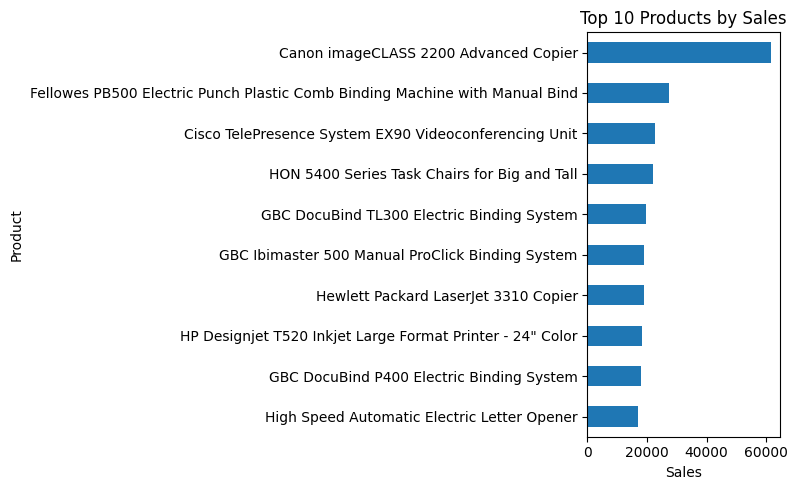

In [22]:
top_products.plot(kind="barh", figsize=(8,5))
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.gca().invert_yaxis()  # highest at top
plt.tight_layout()
plt.savefig("top_products.png")
plt.show()

The dominance of a few products in driving sales highlights the importance of product-level strategy. The business can leverage this insight by ensuring consistent availability of these products, bundling them with lower-performing items, and using them in targeted marketing campaigns to boost overall sales.

## Key Insights

1. High discounts negatively impact profit, suggesting optimization of pricing strategies.

2. Certain regions consistently outperform others, indicating opportunities for expansion.

3. Top product categories drive majority of sales, suggesting focus on high-demand segments.

## Business Recommendations

- Reduce excessive discounting to improve profit margins
- Focus marketing efforts on high-performing regions
- Increase inventory for top-selling products 

## Conclusion

This project demonstrates how data analysis can uncover meaningful business insights. By analyzing sales, profit, and customer trends, we identified key factors influencing performance and provided actionable recommendations for improvement.